In [46]:
# Cell 1: Imports & plotting settings
# (Chạy trong Jupyter notebook)
%matplotlib inline
import os
import re
import unicodedata
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


# Load dữ liệu

In [64]:
# Cell 2: Load dataframe và chuẩn hoá tên cột (snake_case không dấu)
PATH = "data_thuydien.csv"   # chỉnh đường dẫn nếu cần
df = pd.read_csv(PATH)
df

,Tên hồ,Thời điểm,Mực nước thượng lưu (m),Mực nước dâng bình thường (m),Mực nước chết (m),Lưu lượng đến hồ (m3/s),Tổng lượng xả (m3/s),Tổng lượng xả qua đập tràn (m3/s),Tổng lượng xả qua nhà máy (m3/s),Số cửa xả sâu,Số cửa xả mặt
0,Hòa Bình,01/09/2025 00:00,105.09,117,80,3574,993,0,993,0,0
1,Hòa Bình,01/09/2025 01:00,105.13,117,80,2927,861,0,861,0,0
2,Hòa Bình,01/09/2025 02:00,105.17,117,80,2865,798,0,798,0,0
3,Hòa Bình,01/09/2025 03:00,105.20,117,80,2348,796,0,796,0,0
4,Hòa Bình,01/09/2025 04:00,105.23,117,80,2344,792,0,792,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1291,Hòa Bình,24/10/2025 19:00,115.84,117,80,1631,1059,0,1059,0,0
1292,Hòa Bình,24/10/2025 20:00,115.84,117,80,1631,1059,0,1059,0,0
1293,Hòa Bình,24/10/2025 21:00,115.84,117,80,1631,1059,0,1059,0,0
1294,Hòa Bình,24/10/2025 22:00,115.84,117,80,1631,1059,0,1059,0,0


Xử lý tên tiếng việt

In [65]:
def vn_to_snake(s: str) -> str:
    s = str(s).strip()
    s_norm = unicodedata.normalize('NFD', s)
    s_no_accents = ''.join(ch for ch in s_norm if unicodedata.category(ch) != 'Mn')
    s_no_accents = s_no_accents.replace('đ', 'd').replace('Đ', 'D')
    s_snake = re.sub(r'[^a-zA-Z0-9]+', '_', s_no_accents).lower().strip('_')
    if re.match(r'^\d', s_snake or ''):
        s_snake = 'c_' + s_snake
    return s_snake or 'col'

df.rename(columns={c: vn_to_snake(c) for c in df.columns}, inplace=True)

# nếu có cột thoi_diem -> chuyển sang datetime

# quick check
df.head()

,ten_ho,thoi_diem,muc_nuoc_thuong_luu_m,muc_nuoc_dang_binh_thuong_m,muc_nuoc_chet_m,luu_luong_den_ho_m3_s,tong_luong_xa_m3_s,tong_luong_xa_qua_dap_tran_m3_s,tong_luong_xa_qua_nha_may_m3_s,so_cua_xa_sau,so_cua_xa_mat
0,Hòa Bình,01/09/2025 00:00,105.09,117,80,3574,993,0,993,0,0
1,Hòa Bình,01/09/2025 01:00,105.13,117,80,2927,861,0,861,0,0
2,Hòa Bình,01/09/2025 02:00,105.17,117,80,2865,798,0,798,0,0
3,Hòa Bình,01/09/2025 03:00,105.20,117,80,2348,796,0,796,0,0
4,Hòa Bình,01/09/2025 04:00,105.23,117,80,2344,792,0,792,0,0


In [66]:
print("Columns after dropping:")
print(df.last)

Columns after dropping:
<bound method NDFrame.last of         ten_ho         thoi_diem  muc_nuoc_thuong_luu_m  \
0     Hòa Bình  01/09/2025 00:00                 105.09   
1     Hòa Bình  01/09/2025 01:00                 105.13   
2     Hòa Bình  01/09/2025 02:00                 105.17   
3     Hòa Bình  01/09/2025 03:00                 105.20   
4     Hòa Bình  01/09/2025 04:00                 105.23   
...        ...               ...                    ...   
1291  Hòa Bình  24/10/2025 19:00                 115.84   
1292  Hòa Bình  24/10/2025 20:00                 115.84   
1293  Hòa Bình  24/10/2025 21:00                 115.84   
1294  Hòa Bình  24/10/2025 22:00                 115.84   
1295  Hòa Bình  24/10/2025 23:00                 115.84   

      muc_nuoc_dang_binh_thuong_m  muc_nuoc_chet_m  luu_luong_den_ho_m3_s  \
0                             117               80                   3574   
1                             117               80                   2927   
2     

In [67]:
cols_drop = ['ten_ho', 'muc_nuoc_dang_binh_thuong_m', 'muc_nuoc_chet_m', 'tong_luong_xa_m3_s', 'so_cua_xa_sau', 'so_cua_xa_mat']

# Loại bỏ (chỉ xóa nếu tồn tại)
df_export = df.drop(columns=[c for c in cols_drop if c in df.columns])

In [68]:
print("Columns after dropping:")
print(df_export.columns.tolist())

Columns after dropping:
['thoi_diem', 'muc_nuoc_thuong_luu_m', 'luu_luong_den_ho_m3_s', 'tong_luong_xa_qua_dap_tran_m3_s', 'tong_luong_xa_qua_nha_may_m3_s']


In [69]:
#thoi tiet
df_thoitiet = pd.read_csv("HoaBinh_new2.csv")

In [70]:
print(df_thoitiet.head())

               time  temperature_2m (°C)  relative_humidity_2m (%)  \
0  2022-01-01T00:00                 14.5                        94   
1  2022-01-01T01:00                 14.6                        94   
2  2022-01-01T02:00                 14.9                        92   
3  2022-01-01T03:00                 14.9                        94   
4  2022-01-01T04:00                 14.8                        92   

   precipitation (mm)  cloud_cover (%)  
0                 0.0               65  
1                 0.0              100  
2                 0.0              100  
3                 0.0              100  
4                 0.0              100  


In [71]:
#merge df_thoitiet voi df_export theo thoi diem
df_export['thoi_diem'] = pd.to_datetime(df_export['thoi_diem'], format='%d/%m/%Y %H:%M', errors='coerce')
df_thoitiet['time'] = pd.to_datetime(df_thoitiet['time'],  format='%Y-%m-%dT%H:%M', errors='coerce')   
df_merged = pd.merge(df_export, df_thoitiet, left_on='thoi_diem', right_on='time', how='left')  

In [72]:
#to csv
df_export.to_csv("data_thuydien_ex.csv", index=False)

In [73]:
#to csv
df_merged.to_csv("data_thuydien_enriched.csv", index=False)

In [19]:
print("Columns after merge:")
print(df_merged.columns.tolist())

Columns after merge:
['thoi_diem', 'muc_nuoc_thuong_luu_m', 'luu_luong_den_ho_m3_s', 'tong_luong_xa_qua_dap_tran_m3_s', 'tong_luong_xa_qua_nha_may_m3_s', 'time', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'precipitation (mm)', 'cloud_cover (%)']


# Thống kê đơn biến

In [4]:
cols_target = [
    	'tong_luong_xa_m3_s',	'tong_luong_xa_qua_dap_tran_m3_s'	,'tong_luong_xa_qua_nha_may_m3_s'
]

df.to_csv("./data_thuydien/ThuyDien_hoa_binh_cleaned.csv", index=False)


df[cols_target].describe()

,tong_luong_xa_m3_s,tong_luong_xa_qua_dap_tran_m3_s,tong_luong_xa_qua_nha_may_m3_s
count,33264.000000,33264.000000,33264.000000
mean,1552.929503,243.404431,1309.525072
std,1382.093701,904.583857,774.465377
min,23.000000,0.000000,23.000000
25%,596.000000,0.000000,596.000000
50%,1181.000000,0.000000,1181.000000
75%,2171.000000,0.000000,2156.000000
max,10583.000000,8212.000000,2982.000000


# Trực quan hoá đơn biến

In [15]:
# Cell 3: Danh sách biến liên tục cần phân tích và chuyển về numeric an toàn
cols_target = [
    "muc_nuoc_thuong_luu_m",
    "luu_luong_den_ho_m3_s",
    "tong_luong_xa_m3_s",
]

present = [c for c in cols_target if c in df.columns]
missing = [c for c in cols_target if c not in df.columns]
print("Có trong dataset:", present)
if missing:
    print("Không tìm thấy (bỏ qua):", missing)

out_dir = "./data_thuydien/plots_thuydien"

Có trong dataset: ['muc_nuoc_thuong_luu_m', 'luu_luong_den_ho_m3_s', 'tong_luong_xa_m3_s']


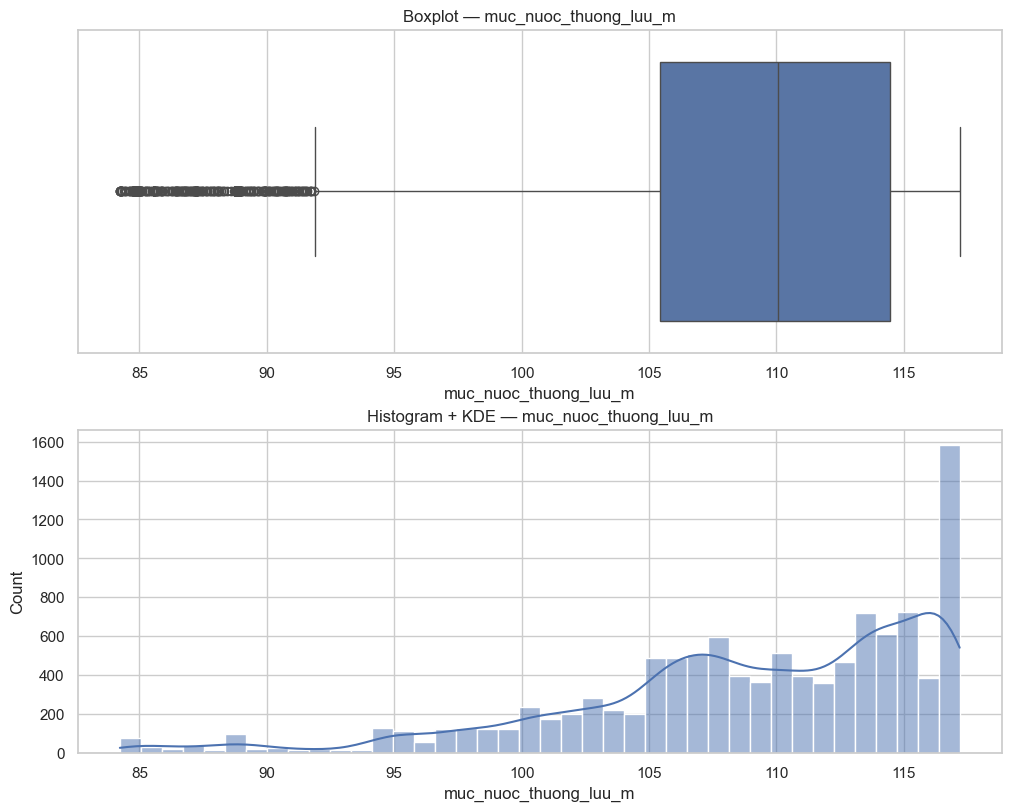

Saved: ./data_thuydien/plots_thuydien\muc_nuoc_thuong_luu_m_box_hist.png


In [18]:
c = "muc_nuoc_thuong_luu_m"
s = df[c].dropna().astype(float)

if s.empty:
    print(f"{c}: không có dữ liệu sau khi clean. Bỏ qua.")
else:
    out_dir = out_dir if 'out_dir' in globals() else "./data_thuydien/plots_thuydien"
    os.makedirs(out_dir, exist_ok=True)

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)

    # Boxplot (hàng trên)
    sns.boxplot(x=s, ax=axes[0])
    axes[0].set_title(f"Boxplot — {c}")
    axes[0].set_xlabel(c)

    # Histogram + KDE (hàng dưới)
    sns.histplot(s, bins=40, kde=True, ax=axes[1])
    axes[1].set_title(f"Histogram + KDE — {c}")
    axes[1].set_xlabel(c)
    axes[1].set_ylabel("Count")

    # Lưu và hiển thị
    fn = os.path.join(out_dir, f"{c}_box_hist.png")
    fig.savefig(fn, bbox_inches='tight', dpi=150)
    plt.show()
    plt.close(fig)

    print(f"Saved: {fn}")

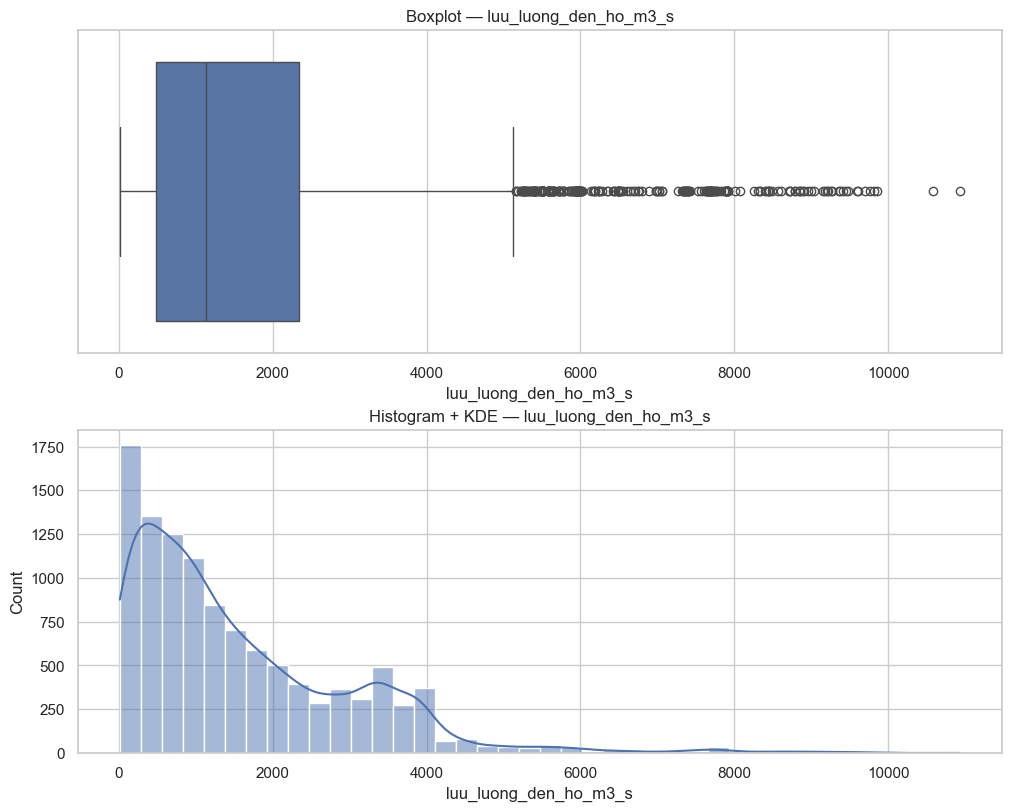

Saved: ./data_thuydien/plots_thuydien\luu_luong_den_ho_m3_s_box_hist.png


In [17]:
c = "luu_luong_den_ho_m3_s"
s = df[c].dropna().astype(float)

if s.empty:
    print(f"{c}: không có dữ liệu sau khi clean. Bỏ qua.")
else:
    out_dir = out_dir if 'out_dir' in globals() else "./data_thuydien/plots_thuydien"
    os.makedirs(out_dir, exist_ok=True)

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)

    # Boxplot (hàng trên)
    sns.boxplot(x=s, ax=axes[0])
    axes[0].set_title(f"Boxplot — {c}")
    axes[0].set_xlabel(c)

    # Histogram + KDE (hàng dưới)
    sns.histplot(s, bins=40, kde=True, ax=axes[1])
    axes[1].set_title(f"Histogram + KDE — {c}")
    axes[1].set_xlabel(c)
    axes[1].set_ylabel("Count")

    # Lưu và hiển thị
    fn = os.path.join(out_dir, f"{c}_box_hist.png")
    fig.savefig(fn, bbox_inches='tight', dpi=150)
    plt.show()
    plt.close(fig)

    print(f"Saved: {fn}")

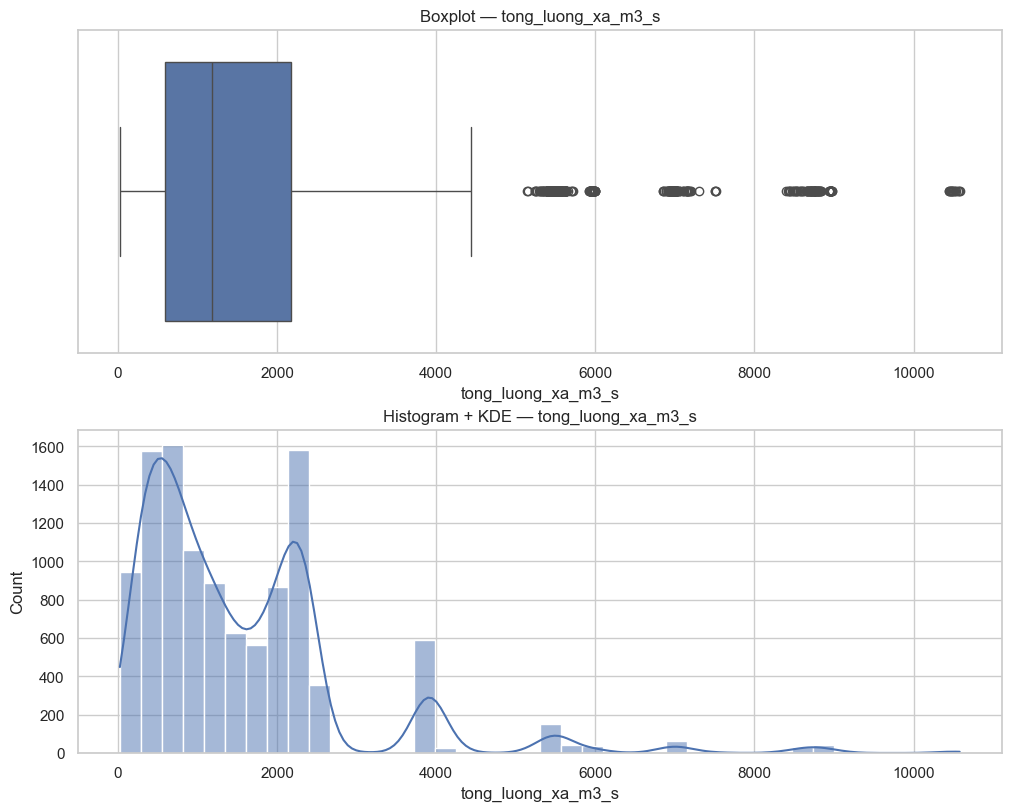

Saved: ./data_thuydien/plots_thuydien\tong_luong_xa_m3_s_box_hist.png


In [16]:
c = "tong_luong_xa_m3_s"
s = df[c].dropna().astype(float)

if s.empty:
    print(f"{c}: không có dữ liệu sau khi clean. Bỏ qua.")
else:
    out_dir = out_dir if 'out_dir' in globals() else "./data_thuydien/plots_thuydien"
    os.makedirs(out_dir, exist_ok=True)

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)

    # Boxplot (hàng trên)
    sns.boxplot(x=s, ax=axes[0])
    axes[0].set_title(f"Boxplot — {c}")
    axes[0].set_xlabel(c)

    # Histogram + KDE (hàng dưới)
    sns.histplot(s, bins=40, kde=True, ax=axes[1])
    axes[1].set_title(f"Histogram + KDE — {c}")
    axes[1].set_xlabel(c)
    axes[1].set_ylabel("Count")

    # Lưu và hiển thị
    fn = os.path.join(out_dir, f"{c}_box_hist.png")
    fig.savefig(fn, bbox_inches='tight', dpi=150)
    plt.show()
    plt.close(fig)

    print(f"Saved: {fn}")

# Trực quan đa biến

## Cái này thiên hướng thống kê

('./data_thuydien/plots_thuydien\\pairplot_sample.png',
 './data_thuydien/plots_thuydien\\correlation_heatmap.png')

<Figure size 1200x1200 with 0 Axes>

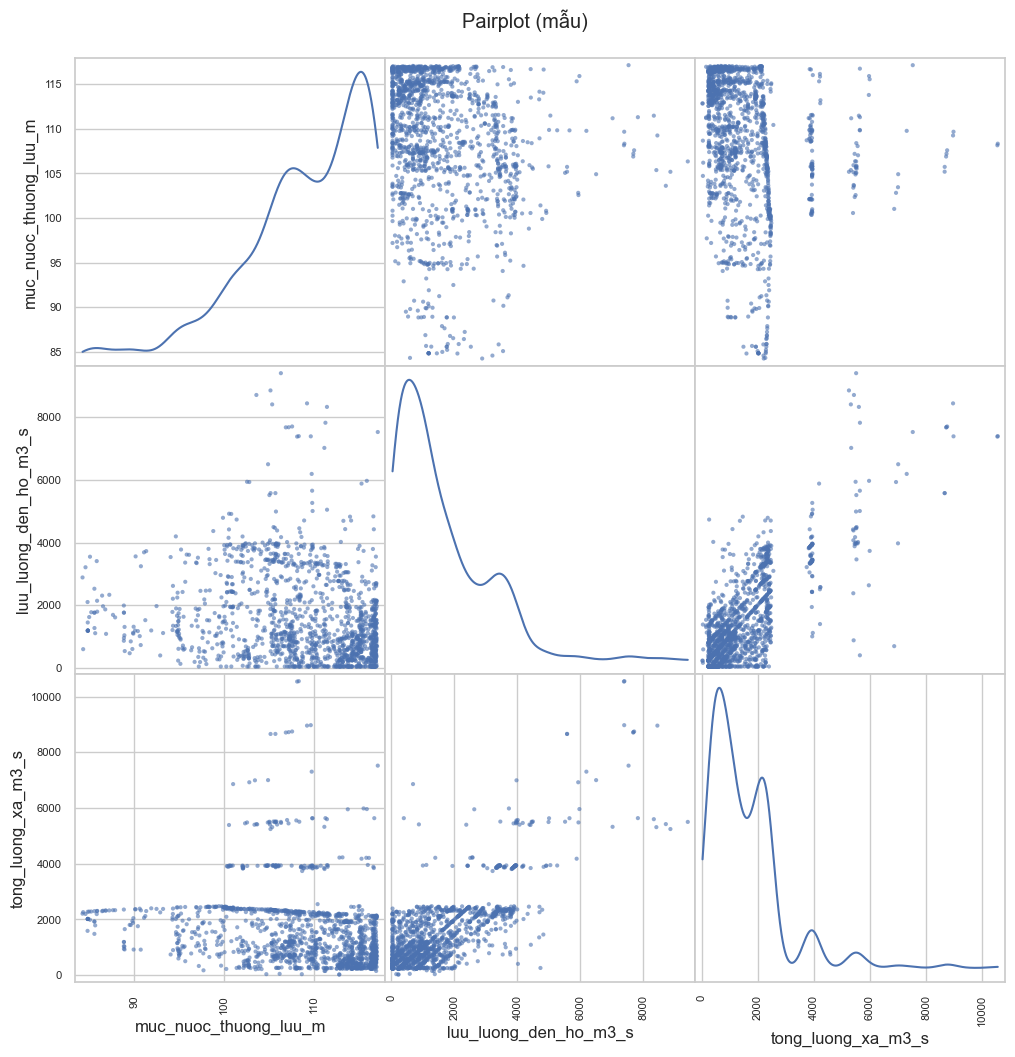

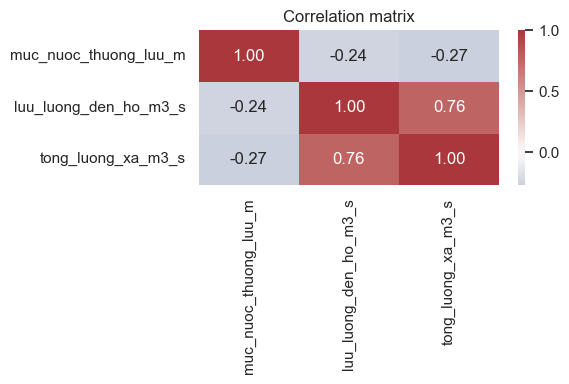

In [44]:
# Create and save pairplot equivalent using pandas.scatter_matrix and correlation heatmap
import os, re, unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns

OUT_DIR = "./data_thuydien/plots_thuydien"
os.makedirs(OUT_DIR, exist_ok=True)

paths = ["./data_thuydien/ThuyDien_hoa_binh.csv", "./data_thuydien/ThuyDien_hoa_binh.csv", "./ThuyDien_hoa_binh.csv"]
df = None
for p in paths:
    try:
        df = pd.read_csv(p)
        break
    except Exception:
        df = None

if df is None:
    raise FileNotFoundError("Không tìm thấy file dữ liệu.")

def vn_to_snake(s: str) -> str:
    s = str(s).strip()
    s_norm = unicodedata.normalize('NFD', s)
    s_no_accents = ''.join(ch for ch in s_norm if unicodedata.category(ch) != 'Mn')
    s_no_accents = s_no_accents.replace('đ', 'd').replace('Đ', 'D')
    s_snake = re.sub(r'[^a-zA-Z0-9]+', '_', s_no_accents).lower().strip('_')
    if s_snake and s_snake[0].isdigit():
        s_snake = 'c_' + s_snake
    return s_snake or 'col'

df.rename(columns={c: vn_to_snake(c) for c in df.columns}, inplace=True)

present = [
    "muc_nuoc_thuong_luu_m",
    "luu_luong_den_ho_m3_s",
    "tong_luong_xa_m3_s"
]
present = [c for c in present if c in df.columns]

# convert to numeric safely by removing commas/spaces
for c in present:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(r'\s+','', regex=True).str.replace(',',''), errors='coerce')

if len(present) >= 2:
    base = df[present].dropna()
    sample_n = min(1500, base.shape[0])
    sample = base.sample(n=sample_n, random_state=42)
    # scatter_matrix as pairplot equivalent
    fig = plt.figure(figsize=(12,12))
    axes = scatter_matrix(sample, diagonal='kde', alpha=0.6, figsize=(12,12))
    plt.suptitle("Pairplot (mẫu)", y=0.92)
    pairplot_path = os.path.join(OUT_DIR, "pairplot_sample.png")
    fig.savefig(pairplot_path, bbox_inches='tight', dpi=150)
else:
    raise ValueError("Không đủ 2 biến để vẽ.")

# Correlation heatmap
if len(present) >= 2:
    # Correlation heatmap
    corr = df[present].corr()
    fig2, ax2 = plt.subplots(figsize=(6,4))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax2)
    ax2.set_title("Correlation matrix")
    plt.tight_layout()
    heatmap_path = os.path.join(OUT_DIR, "correlation_heatmap.png")
    fig2.savefig(heatmap_path, bbox_inches='tight', dpi=150)
else:
    raise ValueError("Không đủ 2 biến để vẽ ma trận tương quan.")

pairplot_path, heatmap_path



## Trực quan hoá đa biến theo từng cặp

### Load dữ liệu

In [38]:
df = pd.read_csv("./data_thuydien/ThuyDien_hoa_binh_cleaned.csv")

cols_target = [
    "thoi_diem",
    "muc_nuoc_thuong_luu_m",
    "luu_luong_den_ho_m3_s",
    "tong_luong_xa_m3_s",
]

df[cols_target]

,thoi_diem,muc_nuoc_thuong_luu_m,luu_luong_den_ho_m3_s,tong_luong_xa_m3_s
0,2025-06-13 20:00:00,84.23,2091,2252
1,2025-06-13 02:00:00,84.24,1764,2260
2,2025-06-13 17:00:00,84.24,1923,2251
3,2025-06-13 23:00:00,84.25,2884,2207
4,2025-06-12 23:00:00,84.27,1430,2261
...,...,...,...,...
11083,2023-12-31 11:00:00,117.06,715,708
11084,2023-12-31 14:00:00,117.06,468,461
11085,2024-09-22 17:00:00,117.11,6349,7502
11086,2024-09-22 20:00:00,117.13,7528,7521


### Mực nước thượng lưu (m) trên từng thời điểm

In [39]:
df['thoi_diem'] = pd.to_datetime(df['thoi_diem'], errors='coerce')
df = df.sort_values('thoi_diem').reset_index(drop=True)
# chọn biến
target = 'muc_nuoc_thuong_luu_m'
df[target] = pd.to_numeric(df[target].astype(str).str.replace(r'\s+','', regex=True).str.replace(',',''), errors='coerce')

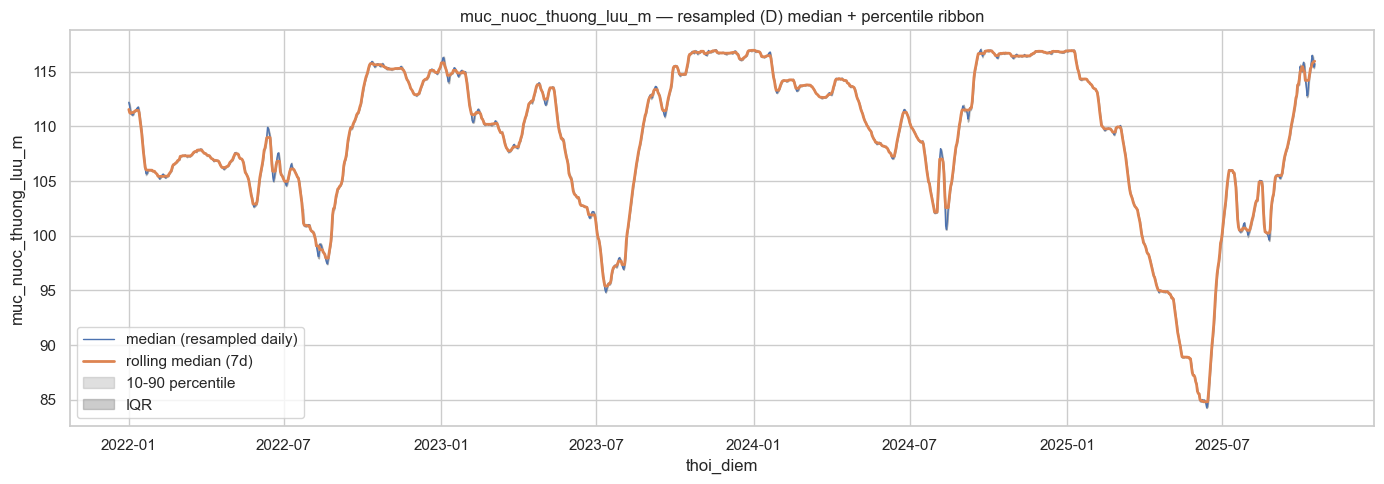

Saved: ./data_thuydien/plots_thuydien\muc_nuoc_thuong_luu_m_resampled_trend_daily.png


In [40]:
# Cell 3 (bản sửa): Resampled trend + percentile ribbon theo NGÀY ('D')
# Cố định freq='D' để mỗi ngày gom ~8 điểm -> P10/P25/P75/P90 & IQR hiện rõ

# Bảo đảm cột thời gian ở dạng datetime và đã sort
df['thoi_diem'] = pd.to_datetime(df['thoi_diem'], errors='coerce')
df = df.sort_values('thoi_diem')

freq = 'D'  # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<  CHỈNH TẠI ĐÂY

series = (
    df.set_index('thoi_diem')[target]
      .resample(freq)
      .agg(['count', 'median', 'mean'])
)

# percentiles per resample (theo NGÀY)
agg_pct = (
    df.set_index('thoi_diem')[target]
      .resample(freq)
      .apply(lambda x: np.percentile(x.dropna(), [10, 25, 75, 90]) if len(x.dropna()) > 0 else [np.nan]*4)
)
pct_df = pd.DataFrame(agg_pct.tolist(), index=agg_pct.index, columns=['p10','p25','p75','p90'])

summary = pd.concat([series, pct_df], axis=1).dropna(subset=['median'])

# rolling median cho daily: 7 ngày
window = 7
summary['roll_median'] = summary['median'].rolling(window=window, min_periods=1, center=True).median()

plt.figure(figsize=(14,5))
plt.plot(summary.index, summary['median'], label='median (resampled daily)', linewidth=1)
plt.plot(summary.index, summary['roll_median'], label=f'rolling median ({window}d)', linewidth=2)
plt.fill_between(summary.index, summary['p10'], summary['p90'], color='grey', alpha=0.25, label='10-90 percentile')
plt.fill_between(summary.index, summary['p25'], summary['p75'], color='grey', alpha=0.40, label='IQR')
plt.legend()
plt.xlabel('thoi_diem'); plt.ylabel(target)
plt.title(f'{target} — resampled ({freq}) median + percentile ribbon')
plt.tight_layout()

# Lưu ảnh
if 'out_dir' not in globals():
    out_dir = "./data_thuydien/plots_thuydien"
import os
os.makedirs(out_dir, exist_ok=True)
fn = os.path.join(out_dir, f"{target}_resampled_trend_daily.png")
plt.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", fn)


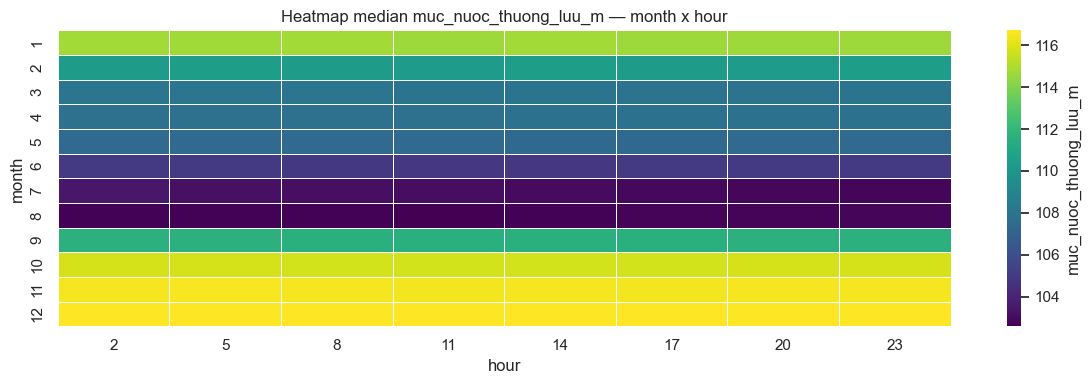

Saved: ./data_thuydien/plots_thuydien\muc_nuoc_thuong_luu_m_month_hour_heatmap.png


In [25]:
# Cell 4: Heatmap month x hour (muốn pattern theo giờ trong năm) — gọn, dễ đọc (12x24)
df2 = df.dropna(subset=['thoi_diem', target]).copy()
df2['month'] = df2['thoi_diem'].dt.month
df2['hour'] = df2['thoi_diem'].dt.hour
pivot = df2.pivot_table(index='month', columns='hour', values=target, aggfunc='median')  # median robust
plt.figure(figsize=(12,4))
sns.heatmap(pivot, cmap='viridis', cbar_kws={'label': target}, linewidths=0.5)
plt.title(f'Heatmap median {target} — month x hour')
plt.ylabel('month'); plt.xlabel('hour')
plt.tight_layout()
fn = os.path.join(out_dir, f"{target}_month_hour_heatmap.png")
plt.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", fn)


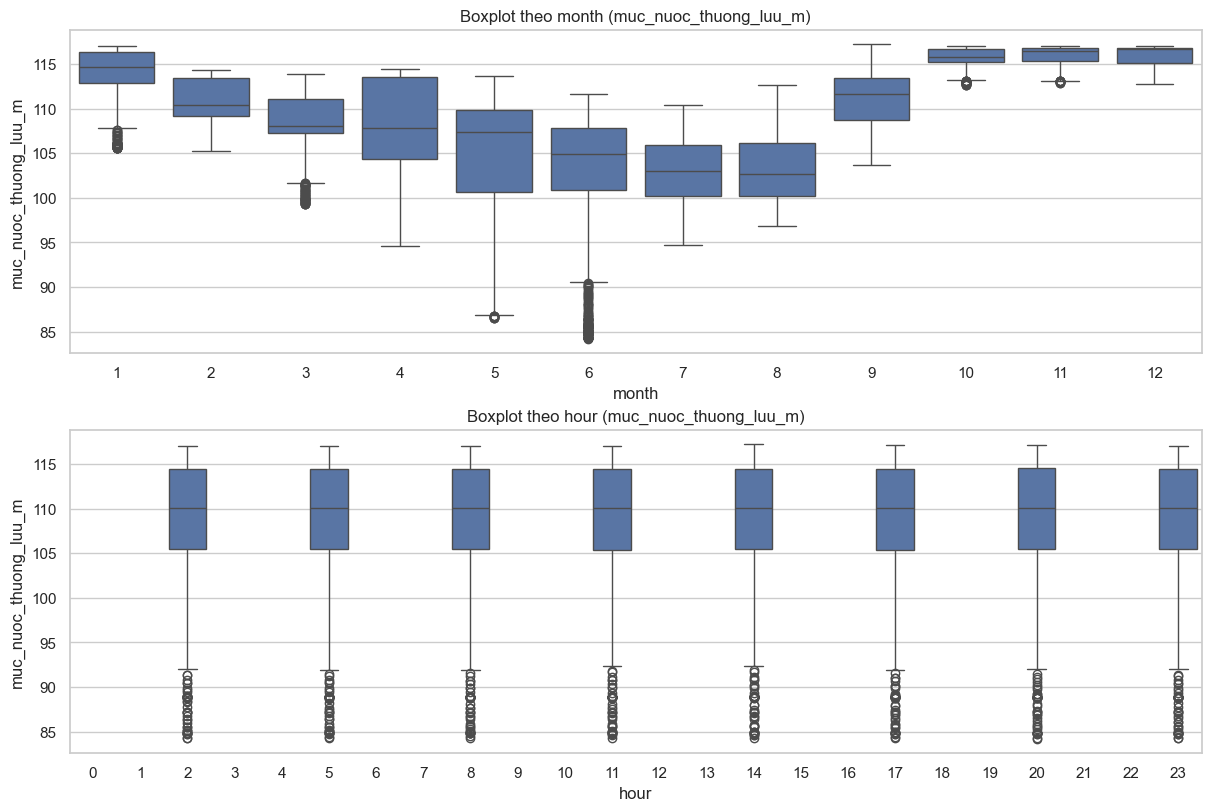

Saved: ./data_thuydien/plots_thuydien\muc_nuoc_thuong_luu_m_box_month_hour.png


In [26]:
# Cell 5: Boxplot by month (12 boxes) + Boxplot by hour (24 boxes) — 2x1 matrix, đơn giản, tổng quát
df_b = df2.copy()
order_month = list(range(1,13))
order_hour = list(range(0,24))

fig, axes = plt.subplots(2,1, figsize=(12,8), constrained_layout=True)
sns.boxplot(x='month', y=target, data=df_b, order=order_month, ax=axes[0])
axes[0].set_title(f'Boxplot theo month ({target})'); axes[0].set_xlabel('month')

sns.boxplot(x='hour', y=target, data=df_b, order=order_hour, ax=axes[1])
axes[1].set_title(f'Boxplot theo hour ({target})'); axes[1].set_xlabel('hour')

fn = os.path.join(out_dir, f"{target}_box_month_hour.png")
fig.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", fn)


### Lưu lượng đến hồ (m3/s) trên từng thời điểm

In [41]:
df['thoi_diem'] = pd.to_datetime(df['thoi_diem'], errors='coerce')
df = df.sort_values('thoi_diem').reset_index(drop=True)
# chọn biến
target = 'luu_luong_den_ho_m3_s'
df[target] = pd.to_numeric(df[target].astype(str).str.replace(r'\s+','', regex=True).str.replace(',',''), errors='coerce')

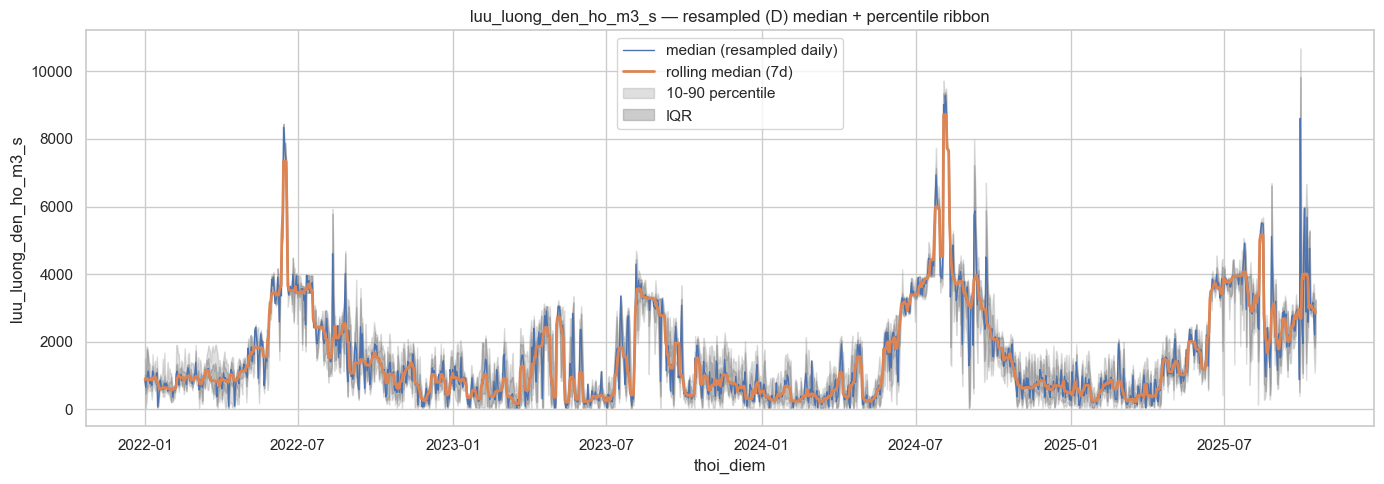

Saved: ./data_thuydien/plots_thuydien\luu_luong_den_ho_m3_s_resampled_trend_daily.png


In [42]:
# Cell 3 (bản sửa): Resampled trend + percentile ribbon theo NGÀY ('D')
# Cố định freq='D' để mỗi ngày gom ~8 điểm -> P10/P25/P75/P90 & IQR hiện rõ

# Bảo đảm cột thời gian ở dạng datetime và đã sort
df['thoi_diem'] = pd.to_datetime(df['thoi_diem'], errors='coerce')
df = df.sort_values('thoi_diem')

freq = 'D'  # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<  CHỈNH TẠI ĐÂY

series = (
    df.set_index('thoi_diem')[target]
      .resample(freq)
      .agg(['count', 'median', 'mean'])
)

# percentiles per resample (theo NGÀY)
agg_pct = (
    df.set_index('thoi_diem')[target]
      .resample(freq)
      .apply(lambda x: np.percentile(x.dropna(), [10, 25, 75, 90]) if len(x.dropna()) > 0 else [np.nan]*4)
)
pct_df = pd.DataFrame(agg_pct.tolist(), index=agg_pct.index, columns=['p10','p25','p75','p90'])

summary = pd.concat([series, pct_df], axis=1).dropna(subset=['median'])

# rolling median cho daily: 7 ngày
window = 7
summary['roll_median'] = summary['median'].rolling(window=window, min_periods=1, center=True).median()

plt.figure(figsize=(14,5))
plt.plot(summary.index, summary['median'], label='median (resampled daily)', linewidth=1)
plt.plot(summary.index, summary['roll_median'], label=f'rolling median ({window}d)', linewidth=2)
plt.fill_between(summary.index, summary['p10'], summary['p90'], color='grey', alpha=0.25, label='10-90 percentile')
plt.fill_between(summary.index, summary['p25'], summary['p75'], color='grey', alpha=0.40, label='IQR')
plt.legend()
plt.xlabel('thoi_diem'); plt.ylabel(target)
plt.title(f'{target} — resampled ({freq}) median + percentile ribbon')
plt.tight_layout()

# Lưu ảnh
if 'out_dir' not in globals():
    out_dir = "./data_thuydien/plots_thuydien"
import os
os.makedirs(out_dir, exist_ok=True)
fn = os.path.join(out_dir, f"{target}_resampled_trend_daily.png")
plt.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", fn)


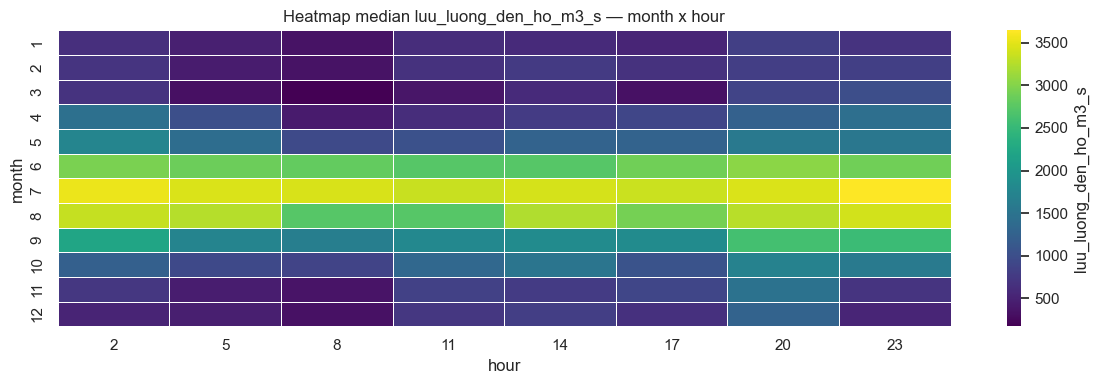

Saved: ./data_thuydien/plots_thuydien\luu_luong_den_ho_m3_s_month_hour_heatmap.png


In [29]:
# Cell 4: Heatmap month x hour (muốn pattern theo giờ trong năm) — gọn, dễ đọc (12x24)
df2 = df.dropna(subset=['thoi_diem', target]).copy()
df2['month'] = df2['thoi_diem'].dt.month
df2['hour'] = df2['thoi_diem'].dt.hour
pivot = df2.pivot_table(index='month', columns='hour', values=target, aggfunc='median')  # median robust
plt.figure(figsize=(12,4))
sns.heatmap(pivot, cmap='viridis', cbar_kws={'label': target}, linewidths=0.5)
plt.title(f'Heatmap median {target} — month x hour')
plt.ylabel('month'); plt.xlabel('hour')
plt.tight_layout()
fn = os.path.join(out_dir, f"{target}_month_hour_heatmap.png")
plt.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", fn)


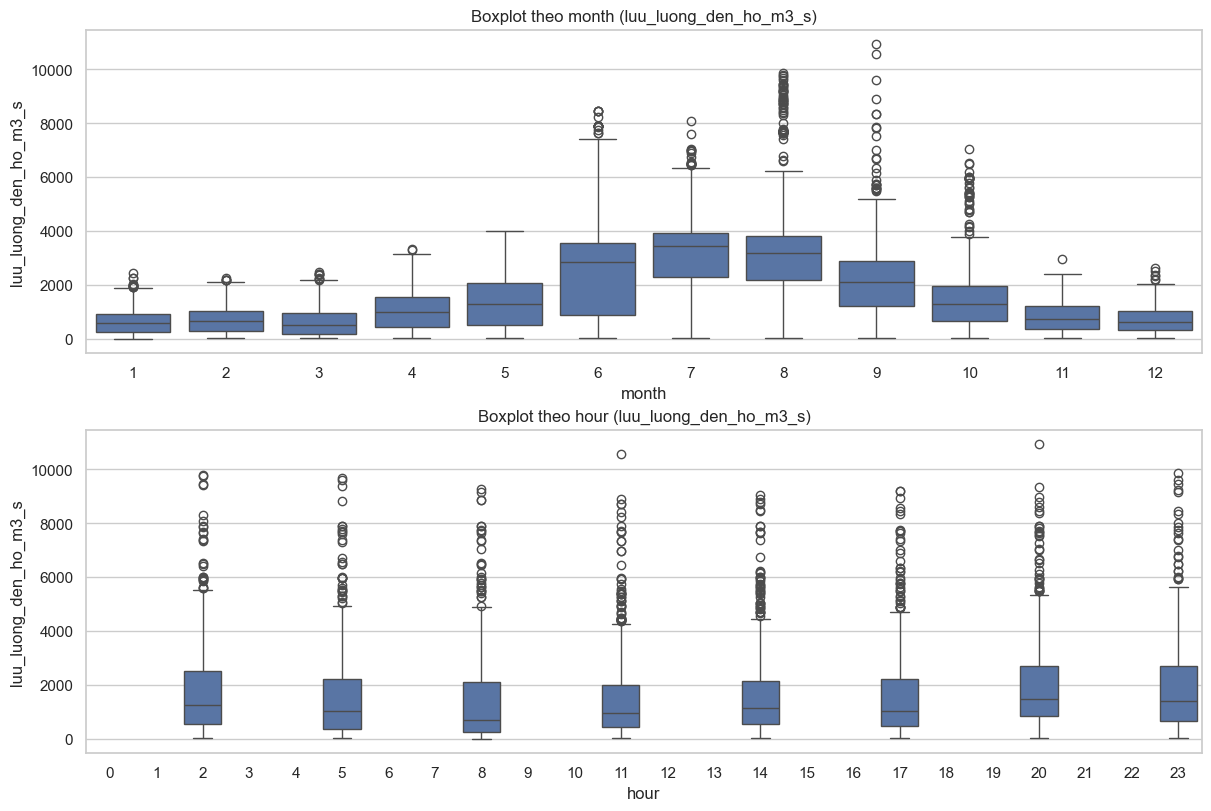

Saved: ./data_thuydien/plots_thuydien\luu_luong_den_ho_m3_s_box_month_hour.png


In [30]:
# Cell 5: Boxplot by month (12 boxes) + Boxplot by hour (24 boxes) — 2x1 matrix, đơn giản, tổng quát
df_b = df2.copy()
order_month = list(range(1,13))
order_hour = list(range(0,24))

fig, axes = plt.subplots(2,1, figsize=(12,8), constrained_layout=True)
sns.boxplot(x='month', y=target, data=df_b, order=order_month, ax=axes[0])
axes[0].set_title(f'Boxplot theo month ({target})'); axes[0].set_xlabel('month')

sns.boxplot(x='hour', y=target, data=df_b, order=order_hour, ax=axes[1])
axes[1].set_title(f'Boxplot theo hour ({target})'); axes[1].set_xlabel('hour')

fn = os.path.join(out_dir, f"{target}_box_month_hour.png")
fig.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", fn)


### Tổng lượng xã (m3/s) trên từng thời điểm

In [43]:
df['thoi_diem'] = pd.to_datetime(df['thoi_diem'], errors='coerce')
df = df.sort_values('thoi_diem').reset_index(drop=True)
# chọn biến
target = 'tong_luong_xa_m3_s'
df[target] = pd.to_numeric(df[target].astype(str).str.replace(r'\s+','', regex=True).str.replace(',',''), errors='coerce')

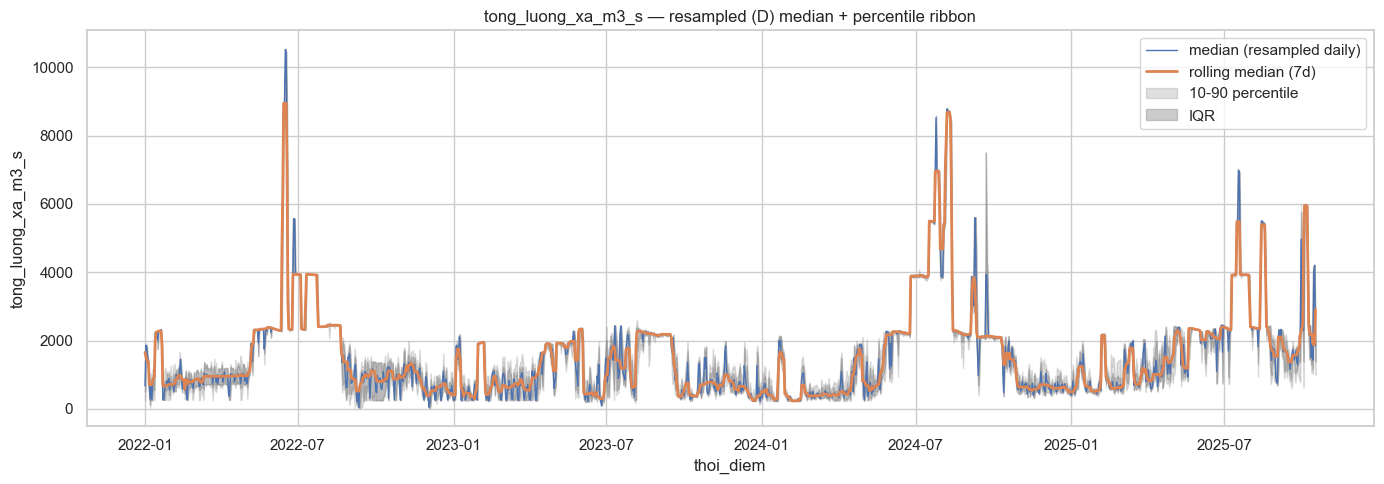

Saved: ./data_thuydien/plots_thuydien\tong_luong_xa_m3_s_resampled_trend_daily.png


In [44]:
# Cell 3 (bản sửa): Resampled trend + percentile ribbon theo NGÀY ('D')
# Cố định freq='D' để mỗi ngày gom ~8 điểm -> P10/P25/P75/P90 & IQR hiện rõ

# Bảo đảm cột thời gian ở dạng datetime và đã sort
df['thoi_diem'] = pd.to_datetime(df['thoi_diem'], errors='coerce')
df = df.sort_values('thoi_diem')

freq = 'D'  # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<  CHỈNH TẠI ĐÂY

series = (
    df.set_index('thoi_diem')[target]
      .resample(freq)
      .agg(['count', 'median', 'mean'])
)

# percentiles per resample (theo NGÀY)
agg_pct = (
    df.set_index('thoi_diem')[target]
      .resample(freq)
      .apply(lambda x: np.percentile(x.dropna(), [10, 25, 75, 90]) if len(x.dropna()) > 0 else [np.nan]*4)
)
pct_df = pd.DataFrame(agg_pct.tolist(), index=agg_pct.index, columns=['p10','p25','p75','p90'])

summary = pd.concat([series, pct_df], axis=1).dropna(subset=['median'])

# rolling median cho daily: 7 ngày
window = 7
summary['roll_median'] = summary['median'].rolling(window=window, min_periods=1, center=True).median()

plt.figure(figsize=(14,5))
plt.plot(summary.index, summary['median'], label='median (resampled daily)', linewidth=1)
plt.plot(summary.index, summary['roll_median'], label=f'rolling median ({window}d)', linewidth=2)
plt.fill_between(summary.index, summary['p10'], summary['p90'], color='grey', alpha=0.25, label='10-90 percentile')
plt.fill_between(summary.index, summary['p25'], summary['p75'], color='grey', alpha=0.40, label='IQR')
plt.legend()
plt.xlabel('thoi_diem'); plt.ylabel(target)
plt.title(f'{target} — resampled ({freq}) median + percentile ribbon')
plt.tight_layout()

# Lưu ảnh
if 'out_dir' not in globals():
    out_dir = "./data_thuydien/plots_thuydien"
import os
os.makedirs(out_dir, exist_ok=True)
fn = os.path.join(out_dir, f"{target}_resampled_trend_daily.png")
plt.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", fn)


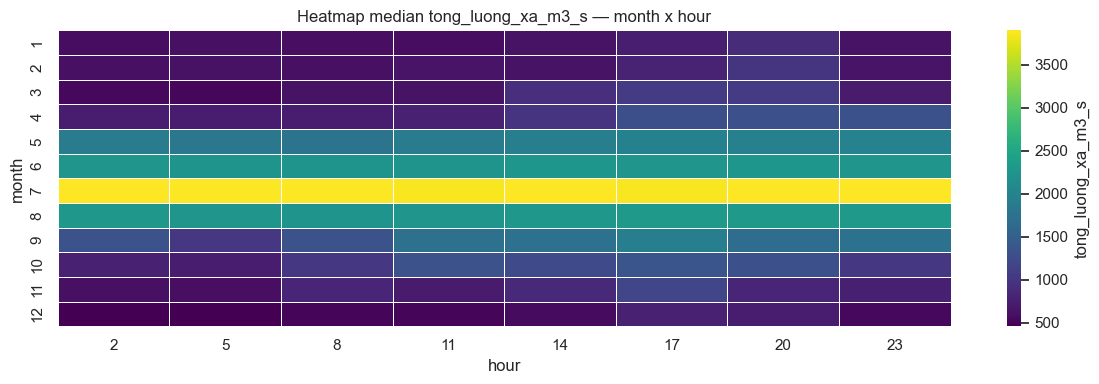

Saved: ./data_thuydien/plots_thuydien\tong_luong_xa_m3_s_month_hour_heatmap.png


In [33]:
# Cell 4: Heatmap month x hour (muốn pattern theo giờ trong năm) — gọn, dễ đọc (12x24)
df2 = df.dropna(subset=['thoi_diem', target]).copy()
df2['month'] = df2['thoi_diem'].dt.month
df2['hour'] = df2['thoi_diem'].dt.hour
pivot = df2.pivot_table(index='month', columns='hour', values=target, aggfunc='median')  # median robust
plt.figure(figsize=(12,4))
sns.heatmap(pivot, cmap='viridis', cbar_kws={'label': target}, linewidths=0.5)
plt.title(f'Heatmap median {target} — month x hour')
plt.ylabel('month'); plt.xlabel('hour')
plt.tight_layout()
fn = os.path.join(out_dir, f"{target}_month_hour_heatmap.png")
plt.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", fn)


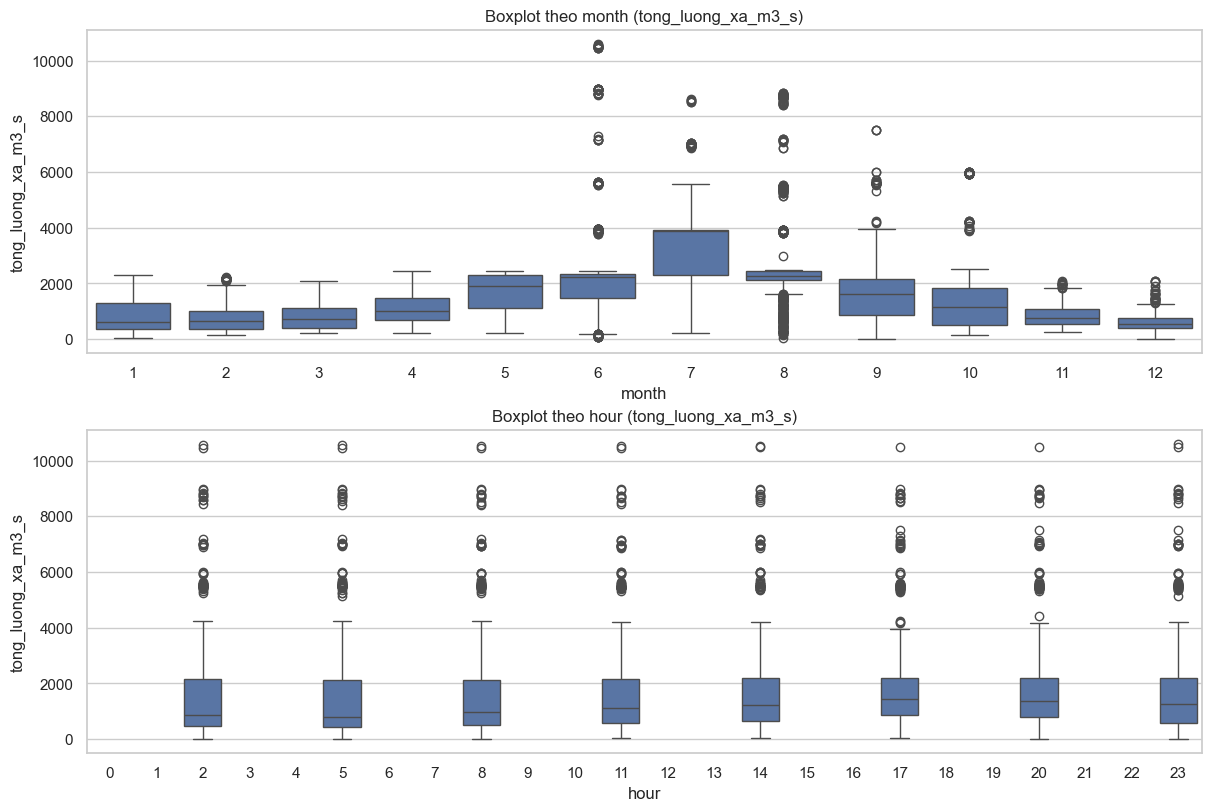

Saved: ./data_thuydien/plots_thuydien\tong_luong_xa_m3_s_box_month_hour.png


In [34]:
# Cell 5: Boxplot by month (12 boxes) + Boxplot by hour (24 boxes) — 2x1 matrix, đơn giản, tổng quát
df_b = df2.copy()
order_month = list(range(1,13))
order_hour = list(range(0,24))

fig, axes = plt.subplots(2,1, figsize=(12,8), constrained_layout=True)
sns.boxplot(x='month', y=target, data=df_b, order=order_month, ax=axes[0])
axes[0].set_title(f'Boxplot theo month ({target})'); axes[0].set_xlabel('month')

sns.boxplot(x='hour', y=target, data=df_b, order=order_hour, ax=axes[1])
axes[1].set_title(f'Boxplot theo hour ({target})'); axes[1].set_xlabel('hour')

fn = os.path.join(out_dir, f"{target}_box_month_hour.png")
fig.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", fn)
